C:\Users\tzp25\AppData\Local\Temp\ipykernel_20716\380640053.py:529: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


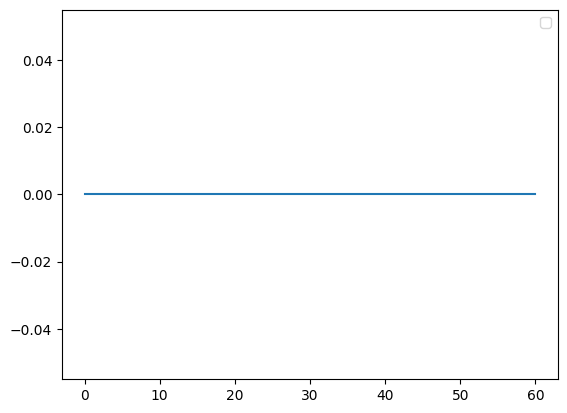

In [ ]:
# This file is designed to contain a number of functions that will frequently be used for our impact processes.

# As our trading strategies are determenistic, we wish to calculate impact, trading costs, and costs due to impact all in closed form

# This decision means that everything that follows is very tedious...

import numpy as np

class TradingProcess:
    def __init__(self, Q_0, start_time, end_time, risk_aversion, times):
        self.Q_0 = Q_0
        self.start_time = start_time
        self.end_time = end_time
        self.risk_aversion = risk_aversion

        self.compute_volumes_and_velocities(times)


    def evaluate_volume(self, time):
        if time < self.start_time:
            return self.Q_0
        elif time > self.end_time:
             return 0
        
        else:
            if self.risk_aversion == 0: # If no risk aversion then we're under TWAP
                return (self.end_time - time) / (self.end_time - self.start_time) * self.Q_0
            
            else:
                return np.sinh(self.risk_aversion * (self.end_time - time)) / np.sinh(self.risk_aversion * (self.end_time - self.start_time)) * self.Q_0

        
    def evaluate_velocity(self, time):
        if time < self.start_time:
            return 0
        elif time > self.end_time:
             return 0
        
        else:
            if self.risk_aversion == 0: # If no risk aversion then we're under TWAP
                return -  self.Q_0 / (self.end_time - self.start_time)
            
            else:
                return - self.risk_aversion * np.cosh(self.risk_aversion * (self.end_time - time)) / np.sinh(self.risk_aversion * (self.end_time - self.start_time)) * self.Q_0

    def volume_vector(self, times):
        times_before_start = np.less(times , self.start_time)
        times_after_end = np.greater(times, self.end_time)
        times_between = np.ones(times.shape) - times_after_end - times_before_start

        if self.risk_aversion == 0: # If no risk aversion then we're under TWAP
            return (self.end_time - times) / (self.end_time - self.start_time) * self.Q_0 * times_between + times_before_start * self.Q_0
        else:
            return np.sinh(self.risk_aversion * (self.end_time - times)) / np.sinh(self.risk_aversion * (self.end_time - self.start_time)) * self.Q_0 * times_between + times_before_start * self.Q_0


    def velocity_vector(self, times):
        times_before_start = np.less(times , self.start_time)
        times_after_end = np.greater(times, self.end_time)
        times_between = np.ones(times.shape) - times_after_end - times_before_start

        if self.risk_aversion == 0: # If no risk aversion then we're under TWAP
            return -  self.Q_0 / (self.end_time - self.start_time) * times_between
            
        else:
            return - self.risk_aversion * np.cosh(self.risk_aversion * (self.end_time - times)) / np.sinh(self.risk_aversion * (self.end_time - self.start_time)) * self.Q_0 * times_between

    def compute_volumes_and_velocities(self, times):
        self.times = times
        self.volume = self.volume_vector(self.times)
        self.velocity = self.velocity_vector(self.times)

        return None

class ImpactProcess:

    def __init__(self, scale, decay, permanent_proportion):
        self.scale = scale # lambda
        self.decay = decay # beta
        self.permanent_proportion = permanent_proportion # p
        self.impact = 0
        self.times = 0

    
    def compute_impact(self, trade_process):
        """Just don't choose beta = gamma please... then I'll have to add that in"""
        times = trade_process.times
        self.times = times
        times_before_start = np.less(times , trade_process.start_time)
        times_after_end = np.greater(times, trade_process.end_time)
        times_between = np.ones(times.shape) - times_after_end - times_before_start

        if trade_process.risk_aversion == 0:
            I_0 = 0
            A = - (1 - self.permanent_proportion) / self.decay * (1 - np.exp(- self.decay * (times - trade_process.start_time)))
            B = - self.permanent_proportion * (times - trade_process.start_time)
            I_1 = (A + B) * self.scale * trade_process.Q_0 / (trade_process.end_time - trade_process.start_time) 
            
            C = - (1 - self.permanent_proportion) / (trade_process.end_time - trade_process.start_time) / self.decay * (np.exp(self.decay * (trade_process.end_time - times)) - np.exp(self.decay * (trade_process.start_time - times)))
            D = - self.permanent_proportion
            I_2 = (C + D) * trade_process.Q_0 * self.scale

            self.impact = I_0 * times_before_start + I_1 * times_between + I_2 * times_after_end

            return self.impact
        
        else:
            I_0 = 0

            A = np.exp(trade_process.risk_aversion * trade_process.end_time) / (self.decay - trade_process.risk_aversion) * (np.exp((self.decay - trade_process.risk_aversion) * times) - np.exp((self.decay - trade_process.risk_aversion) * trade_process.start_time))
            B = np.exp(- trade_process.risk_aversion * trade_process.end_time) / (self.decay + trade_process.risk_aversion) * (np.exp((self.decay + trade_process.risk_aversion) * times) - np.exp((self.decay + trade_process.risk_aversion) * trade_process.start_time))
            C = - trade_process.Q_0 * trade_process.risk_aversion * (1 - self.permanent_proportion) * self.scale * np.exp(-self.decay * times)
            D = 2 * np.sinh(trade_process.risk_aversion * (trade_process.end_time - trade_process.start_time))

            E = self.permanent_proportion * self.scale * trade_process.Q_0 * (np.sinh(trade_process.risk_aversion * (trade_process.end_time - times))/np.sinh(trade_process.risk_aversion *(trade_process.end_time - trade_process.start_time)) - 1)

            I_1 = C/D * (A + B) + E

            F = np.exp(trade_process.risk_aversion * trade_process.end_time) / (self.decay - trade_process.risk_aversion) * (np.exp((self.decay - trade_process.risk_aversion) * trade_process.end_time) - np.exp((self.decay - trade_process.risk_aversion) * trade_process.start_time))
            G = np.exp(- trade_process.risk_aversion * trade_process.end_time) / (self.decay + trade_process.risk_aversion) * (np.exp((self.decay + trade_process.risk_aversion) * trade_process.end_time) - np.exp((self.decay + trade_process.risk_aversion) * trade_process.start_time))
            I_2 = C/D * (F + G) - self.permanent_proportion * self.scale * trade_process.Q_0

            self.impact = I_0 * times_before_start + I_1 * times_between + I_2 * times_after_end

            return self.impact
        
    def impact_cost(self, impact_trades, cost_trades):
        
        times = cost_trades.times

        t_i = cost_trades.start_time
        T_i = cost_trades.end_time

        t_j = impact_trades.start_time
        T_j = impact_trades.end_time

        result = np.zeros(times.shape)

        # Our strategy is to compute each of the integrals in turn, and then add them on to the result

        # Limits for integral_1, unused but defined for completeness

        a_1 = np.max([0,t_i])
        b_1 = np.maximum(np.minimum(times, np.min([t_j, T_i])), a_1)


        # Limits for integral_2

        a_2 = np.max([0,t_i, t_j])
        b_2 = np.maximum(np.minimum(times, np.min([T_j, T_i])), a_2)


        # Limits for integral_3

        a_3 = np.max([0,t_i, T_j])
        b_3 = np.maximum(np.minimum(times, T_i), a_3)


        # Define terms as in Thesis for familiarity and to ease bug checking
        beta = self.decay
        lambdas = self.scale
        p = self.permanent_proportion
        
        gamma_i = cost_trades.risk_aversion
        Q_i = cost_trades.Q_0

        gamma_j = impact_trades.risk_aversion
        Q_j = impact_trades.Q_0


        

        
        
        # Risk Averse Impact
        if gamma_j > 0:
            X = -Q_j * gamma_j * (1-p) * lambdas / 2 / np.sinh(gamma_j * (T_j - t_j))

            # p = 0 terms

            A_j = X * np.exp(gamma_j * T_j) / (beta - gamma_j)

            B_j = X * np.exp(-gamma_j * T_j) / (beta + gamma_j)

            C_j = - X *( np.exp(-gamma_j * T_j) / (beta - gamma_j) * np.exp((beta - gamma_j) * t_j) + np.exp(-gamma_j * T_j) / (beta + gamma_j) * np.exp((beta+gamma_j) * t_j) )

            

            # p = 1 terms

            D_j = - p * lambdas * Q_j 

            J_j = p * lambdas * Q_j / np.sinh(gamma_j * (T_j - t_j))


            # Integral 3 terms

            E_j = - Q_j * gamma_j * (1-p) * lambdas / 2 / np.sinh(gamma_j * (T_j - t_j)) * (np.exp(gamma_j * T_j) / (beta - gamma_j) * (np.exp((beta - gamma_j) * T_j) - np.exp((beta - gamma_j) * t_j)) + np.exp(- gamma_j * T_j) / (beta + gamma_j) * (np.exp((beta + gamma_j) * T_j) - np.exp((beta + gamma_j) * t_j)))

            F_j = - Q_j * p * lambdas
        
            # Risk Averse Liquidation

            if gamma_i > 0:
                G_i = - Q_i * gamma_i * np.exp(gamma_i * T_i) / 2 / np.sinh(gamma_i * (T_i - t_i))

                H_i = - Q_i * gamma_i * np.exp(-gamma_i * T_i) / 2 / np.sinh(gamma_i * (T_i - t_i))

                L_i = - Q_i * gamma_i / np.sinh(gamma_i * (T_i - t_i))
                
                # Computing Integral 2
                if gamma_i != gamma_j:

                    # p = 1 terms

                    term_1 = - D_j * L_i / gamma_i * (np.sinh(gamma_i * (T_i - b_2)) - np.sinh(gamma_i * (T_i - a_2)))

                    term_2 = - J_j * L_i / 2 * (np.cosh((gamma_j*T_j + gamma_i*T_i) - (gamma_j + gamma_i) * b_2) / (gamma_j + gamma_i) - np.cosh((gamma_j*T_j + gamma_i*T_i) - (gamma_j + gamma_i) * a_2) / (gamma_j + gamma_i) + np.cosh(gamma_j * T_j - gamma_i * T_i - (gamma_j - gamma_i) * b_2)/(gamma_j - gamma_i) - np.cosh(gamma_j * T_j - gamma_i * T_i - (gamma_j - gamma_i) * a_2)/(gamma_j - gamma_i))


                    # p = 0 terms

                    C = - Q_i * Q_j * gamma_i * gamma_j * (1-p) * lambdas / 2 / np.sinh(gamma_j * (T_j - t_j)) / np.sinh(gamma_i * (T_i - t_i))
                    A_1 = np.exp(gamma_j * T_j) / (beta - gamma_j)
                    A_2 = np.exp(-gamma_j * T_j) / (beta + gamma_j)

                    def J(k):
                        lhs = np.exp(gamma_i * T_i) / (k - gamma_i) * ((np.exp((k - gamma_i) * b_2)) - np.exp((k - gamma_i) * a_2))
                        rhs = np.exp(-gamma_i * T_i) / (k + gamma_i) * ((np.exp((k + gamma_i) * b_2)) - np.exp((k + gamma_i) * a_2))
                        return 0.5 * (lhs + rhs)

                    term_3 = A_1 * (J(-gamma_j) - np.exp((beta - gamma_j) * t_j) * J(-beta))

                    term_4 = A_2 * (J(gamma_j) - np.exp((beta + gamma_j) *t_j) * J(-beta))

                    integral_2 = term_1 + term_2 - C * (term_3 + term_4)

                    

                if gamma_i == gamma_j:

                    # p = 1 terms

                    term_1 = - D_j * L_i / gamma_i * (np.sinh(gamma_i * (T_i - b_2)) - np.sinh(gamma_i * (T_i - a_2)))

                    term_2 = J_j * L_i / 2 * np.sinh(gamma_i * (T_j - T_i)) * (b_2 - a_2)
                    
                    term_3 = -J_j * L_i / 4 / gamma_i * (np.cosh(gamma_i * (T_i + T_j - 2 * b_2)) - np.cosh(gamma_i * (T_i + T_j - 2 * a_2)))
                    
                    # p = 0 terms

                    C = - Q_i * Q_j * gamma_i * gamma_j * (1-p) * lambdas / 2 / np.sinh(gamma_j * (T_j - t_j)) / np.sinh(gamma_i * (T_i - t_i))
                    A_1 = np.exp(gamma_j * T_j) / (beta - gamma_j)
                    A_2 = np.exp(-gamma_j * T_j) / (beta + gamma_j)

                    T_minus = (b_2 - a_2) / 2 * np.exp(-gamma_i * T_i) + np.exp(gamma_i * T_i) / 4 / gamma_i * (np.exp(- 2 * gamma_i * a_2) - np.exp(- 2 * gamma_i * b_2))

                    T_plus = (b_2 - a_2) / 2 * np.exp(gamma_i * T_i) + np.exp(-gamma_i * T_i) / 4 / gamma_i * (np.exp(2 * gamma_i * b_2) - np.exp(2 * gamma_i * a_2))

                    def J(k):
                        lhs = np.exp(gamma_i * T_i) / (k - gamma_i) * ((np.exp((k - gamma_i) * b_2)) - np.exp((k - gamma_i) * a_2))
                        rhs = np.exp(-gamma_i * T_i) / (k + gamma_i) * ((np.exp((k + gamma_i) * b_2)) - np.exp((k + gamma_i) * a_2))
                        return 0.5 * (lhs + rhs)

                    T_0 = J(-beta)

                    term_4 = A_1 * (T_minus - np.exp((beta - gamma_j) *t_j) * T_0)

                    term_5 = A_2 * (T_plus - np.exp((beta + gamma_j) * t_j) * T_0)

                    integral_2 = term_1 + term_2 + term_3 - C * (term_4 + term_5)

                    

                # Integral three

                term_1 = - E_j * G_i / (beta + gamma_i) * (np.exp(-(beta + gamma_i) * b_3) - np.exp(-(beta + gamma_i) * a_3))
                term_2 = E_j * H_i / (gamma_i - beta) * (np.exp((gamma_i - beta) * b_3) - np.exp((gamma_i - beta) * a_3))
                term_3 = - F_j * G_i / gamma_i * (np.exp(- gamma_i * b_3) - np.exp(- gamma_i * a_3))
                term_4 = F_j * H_i / gamma_i * (np.exp(gamma_i * b_3) - np.exp(gamma_i * a_3))

                integral_3 = term_1 + term_2 + term_3 + term_4

                result = integral_2 + integral_3

            # TWAP Liquidation
            elif gamma_i == 0:

                K_i = - Q_i / (T_i - t_i)

                # Integral 2

                # p = 0

                term_1 = - p * lambdas * Q_j / np.sinh(gamma_j * (T_j - t_j)) / gamma_j * (np.cosh(gamma_j * (T_j - b_2)) - np.cosh(gamma_j * (T_j - a_2)))

                term_2 = - p * lambdas * Q_j * (b_2 - a_2)


                # p = 1

                def F(k):
                    lhs = np.exp(gamma_j * T_j) / (beta - gamma_j) * (np.exp(-gamma_j * k) / (-gamma_j) - np.exp((beta - gamma_j) * t_j) * np.exp(-beta * k) / (-beta))
                    rhs = np.exp(-gamma_j * T_j) / (beta + gamma_j) * (np.exp(gamma_j * k) / gamma_j - np.exp((beta + gamma_j) * t_j) * np.exp(-beta * k) / (-beta))

                    return - Q_j * gamma_j * (1-p) * lambdas / 2 / np.sinh(gamma_j * (T_j - t_j)) * (lhs + rhs)

                term_3 = F(b_2)

                term_4 = -F(a_2)

                integral_2 = K_i * (term_1 + term_2 + term_3 + term_4)

                # Integral 3

                term_1 = - E_j / beta * (np.exp(-beta * b_3) - np.exp(-beta * a_3))
                term_2 = F_j * (b_3 - a_3)

                integral_3 = K_i * (term_1 + term_2)

                result = integral_2 + integral_3

        # TWAP Impact
        elif gamma_j == 0:

            A_j =   Q_j * p * lambdas * t_j / (T_j - t_j)



            E_j = - Q_j * (1-p) * lambdas / (T_j - t_j) / beta * (np.exp(beta * T_j) - np.exp(beta * t_j))

            B_j = - Q_j * p * lambdas / (T_j - t_j)

            D_j = - Q_j * p * lambdas

            


            # Risk Averse Liquidation

            if gamma_i > 0:

                # Integral 1 terms

                # p = 1 terms

                A_j =   Q_j * p * lambdas * t_j / (T_j - t_j)

                B_j = - Q_j * p * lambdas / (T_j - t_j)


                # Integral 3 terms

                E_j = - Q_j * (1-p) * lambdas / (T_j - t_j) / beta * (np.exp(beta * T_j) - np.exp(beta * t_j))

                D_j = - Q_j * p * lambdas

                
                G_i = -Q_i * gamma_i * np.exp(gamma_i * T_i) / 2 / np.sinh(gamma_i * (T_i - t_i))

                H_i = -Q_i * gamma_i * np.exp(-gamma_i * T_i) / 2 / np.sinh(gamma_i * (T_i - t_i))

                # Integral 2

                # p = 1 terms

                term_1 = - A_j * G_i / gamma_i * (np.exp(-gamma_i * b_2) - np.exp(-gamma_i * a_2))

                term_2 = A_j * H_i / gamma_i * (np.exp(gamma_i * b_2) - np.exp(gamma_i * a_2))

                term_3 = B_j * G_i * (- b_2 * np.exp(-gamma_i * b_2) / gamma_i - np.exp(-gamma_i * b_2) / gamma_i / gamma_i + a_2 * np.exp(-gamma_i * a_2) / gamma_i + np.exp(-gamma_i * a_2) / gamma_i / gamma_i)

                term_4 = B_j * H_i * (b_2 * np.exp(gamma_i * b_2) / gamma_i - np.exp(gamma_i * b_2) / gamma_i / gamma_i - a_2 * np.exp(gamma_i * a_2) / gamma_i + np.exp(gamma_i * a_2) / gamma_i /gamma_i)

                # p = 0 terms

                def G(k):
                    C = Q_i * Q_j * (1-p) * lambdas * gamma_i / beta / (T_j - t_j) / np.sinh(gamma_i * (T_i - t_i))

                    lhs = -0.5 * np.exp(gamma_i * T_i + beta * t_j) * np.exp(-(beta + gamma_i) * k) / (-beta + gamma_i)
                    rhs = -0.5 * np.exp(-gamma_i * T_i + beta * t_j) * np.exp((gamma_i - beta) * k) / (gamma_i - beta)

                    return C * (-np.sinh(gamma_i * (T_i - k)) / gamma_i + lhs + rhs)
                
                term_5 = G(b_2) - G(a_2)

                integral_2 = term_1 + term_2 + term_3 + term_4 + term_5

                # Integral 3

                term_1 = - D_j * G_i / gamma_i * (np.exp(-gamma_i * b_3) - np.exp(- gamma_i * a_3))

                term_2 = D_j * H_i / gamma_i * (np.exp(gamma_i * b_3) - np.exp(gamma_i * a_3))

                term_3 = -E_j * G_i / (beta + gamma_i) * (np.exp(-(beta + gamma_i) * b_3) - np.exp(-(beta + gamma_i) * a_3))

                term_4 = E_j * H_i / (gamma_i - beta) * (np.exp((gamma_i - beta) * b_3) - np.exp((gamma_i - beta) * a_3))

                integral_3 = term_1 + term_2 + term_3 + term_4

                result = integral_2 + integral_3

            # TWAP Liquidation
            if gamma_i == 0:

                A_j =   Q_j * p * lambdas * t_j / (T_j - t_j)



                E_j = - Q_j * (1-p) * lambdas / (T_j - t_j) / beta * (np.exp(beta * T_j) - np.exp(beta * t_j))

                B_j = - Q_j * p * lambdas / (T_j - t_j)

                D_j = - Q_j * p * lambdas

                K_i = - Q_i / (T_i - t_i)

                # Integral 2

                term_1 = A_j * K_i * (b_2 - a_2)

                term_2 = B_j * K_i / 2 * (b_2 * b_2 - a_2 * a_2)

                K = Q_i * Q_j * (1-p) * lambdas / beta / (T_j - t_j) / (T_i - t_i)

                term_exp = (np.exp(-beta * (a_2 - t_j)) - np.exp(-beta * (b_2 - t_j))) / beta
                term_3 = K * ((b_2 - a_2) - term_exp)

                integral_2 = term_1 + term_2 + term_3

                # Integral 3

                term_1 = D_j * K_i * (b_3 - a_3)

                term_2 = - E_j * K_i / beta * (np.exp(-beta * b_3) - np.exp(-beta * a_3))

                integral_3 = term_1 + term_2

                result = integral_2 + integral_3

        return result
        

class TradingCost:
    def __init__(self, phi):
        self.phi = phi

    def compute_costs(self, trading_process_1, trading_process_2):
        "Make sure both trading processes have their times set before calling"
        times = trading_process_1.times
        lower_limit = np.max([0, trading_process_1.start_time, trading_process_2.start_time])
        upper_limit = np.minimum(np.min([trading_process_1.end_time, trading_process_2.end_time]), times)
        times_after_lower_limit = np.greater(times, lower_limit)

        if (trading_process_1.risk_aversion == 0) and (trading_process_2.risk_aversion == 0): # TWAP and TWAP
            return_value =  self.phi * ((upper_limit - lower_limit) * trading_process_1.Q_0 * trading_process_2.Q_0 / (trading_process_1.end_time - trading_process_1.start_time) / (trading_process_2.end_time - trading_process_2.start_time) * times_after_lower_limit)

        elif (trading_process_1.risk_aversion == 0): # TWAP and Risk Averse
            A = - trading_process_1.Q_0 * trading_process_2.Q_0 / (trading_process_1.end_time - trading_process_1.start_time) / np.sinh(trading_process_2.risk_aversion * (trading_process_2.end_time - trading_process_2.start_time))  

            return_value = self.phi * ( A * (np.sinh(trading_process_2.risk_aversion * (trading_process_2.end_time - upper_limit)) - np.sinh(trading_process_2.risk_aversion * (trading_process_2.end_time - lower_limit))) ) * times_after_lower_limit
        
        elif (trading_process_2.risk_aversion == 0): # Risk Averse and TWAP
            A = - trading_process_2.Q_0 * trading_process_1.Q_0 / (trading_process_2.end_time - trading_process_2.start_time) / np.sinh(trading_process_1.risk_aversion * (trading_process_1.end_time - trading_process_1.start_time))  

            return_value = self.phi * ( A * (np.sinh(trading_process_1.risk_aversion * (trading_process_1.end_time - upper_limit)) - np.sinh(trading_process_1.risk_aversion * (trading_process_1.end_time - lower_limit))) ) *times_after_lower_limit

        elif (trading_process_1.risk_aversion != trading_process_2.risk_aversion):
            A = np.sinh(trading_process_1.risk_aversion * trading_process_1.end_time + trading_process_2.risk_aversion * trading_process_2.end_time - (trading_process_1.risk_aversion + trading_process_2.risk_aversion) * upper_limit) / (trading_process_1.risk_aversion + trading_process_2.risk_aversion)
            B = np.sinh(trading_process_1.risk_aversion * trading_process_1.end_time - trading_process_2.risk_aversion * trading_process_2.end_time - (trading_process_1.risk_aversion - trading_process_2.risk_aversion) * upper_limit) / (trading_process_1.risk_aversion - trading_process_2.risk_aversion)

            D = np.sinh(trading_process_1.risk_aversion * trading_process_1.end_time + trading_process_2.risk_aversion * trading_process_2.end_time - (trading_process_1.risk_aversion + trading_process_2.risk_aversion) * lower_limit) / (trading_process_1.risk_aversion + trading_process_2.risk_aversion)
            E = np.sinh(trading_process_1.risk_aversion * trading_process_1.end_time - trading_process_2.risk_aversion * trading_process_2.end_time - (trading_process_1.risk_aversion - trading_process_2.risk_aversion) * lower_limit) / (trading_process_1.risk_aversion - trading_process_2.risk_aversion)

            C = trading_process_1.Q_0 * trading_process_2.Q_0 * trading_process_1.risk_aversion * trading_process_2.risk_aversion / np.sinh(trading_process_1.risk_aversion * (trading_process_1.end_time - trading_process_1.start_time)) / np.sinh(trading_process_2.risk_aversion * (trading_process_2.end_time - trading_process_2.start_time))

            return_value = self.phi * (- C / 2 * (A + B - D - E) * times_after_lower_limit)
        
        else:
            A = np.sinh(trading_process_1.risk_aversion * ((trading_process_1.end_time + trading_process_2.end_time) - 2 * upper_limit )) / 2 / trading_process_1.risk_aversion - np.cosh(trading_process_1.risk_aversion * (trading_process_1.end_time - trading_process_2.end_time)) * upper_limit
            B = np.sinh(trading_process_1.risk_aversion * ((trading_process_1.end_time + trading_process_2.end_time) - 2 * lower_limit )) / 2 / trading_process_1.risk_aversion - np.cosh(trading_process_1.risk_aversion * (trading_process_1.end_time - trading_process_2.end_time)) * lower_limit


            C = trading_process_1.Q_0 * trading_process_2.Q_0 * trading_process_1.risk_aversion * trading_process_2.risk_aversion / np.sinh(trading_process_1.risk_aversion * (trading_process_1.end_time - trading_process_1.start_time)) / np.sinh(trading_process_2.risk_aversion * (trading_process_2.end_time - trading_process_2.start_time))
            return_value = self.phi * ( - C / 2 * (A - B) ) * times_after_lower_limit 

        # Set very small values to zero
        return_value[return_value < 0.0001]  = 0

        return return_value


#########################################################################

import matplotlib.pyplot as plt

maturity = 60

steps = 300

times = np.linspace(0, maturity, steps)

impact = ImpactProcess(4, 2, 0.1)

process_1 = TradingProcess(1, 0, 1, 0.1, times)

process_2 = TradingProcess(1, 2, 6, 0.3, times)

trading_costs = TradingCost(0.01 * 0.012791624621594347) 

process_1_and_2_costs = impact.impact_cost(process_1, process_2)

plt.plot(times, impact.compute_impact(process_1), label = 'impact')

plt.plot(times, process_2.velocity, label = 'velocity')

product = impact.compute_impact(process_1) * process_2.velocity

plt.plot(times, product, label = 'impact velocity product')

# numerical_integral = product.cumsum() * maturity/steps

# plt.plot(times, numerical_integral, label = 'numerical integral')

plt.plot(times, process_1_and_2_costs, label = 'impact velocity integral')

plt.plot(times, trading_costs.compute_costs(process_1, process_2))

plt.legend()

plt.show()


In [46]:
import ImpactFunctions

import numpy as np


# The goal of this file is to create a general process, and then compute the costs from the trading of the agents

class AuxilliaryStockProcesses:
    # To compute cost and impact processes for an individual stock
    def __init__(self, times, agents, impact_functions, trading_cost_functions, stock_name, stock_value):
        self.times = times # np array of times, starting at 0
        self.agents = agents # np array or list of agents
        self.impact_function = impact_functions[stock_name] # ImpactProcesses - to compute impacts, costs due to impact 
        self.trading_cost_function = trading_cost_functions[stock_name]  # TradingCost - to compute trading costs, costs due to trades
        self.stock_name = stock_name
        self.stock_value = stock_value


    def compute_impact_costs(self):
        """Computes the impact costs for each agent for the stock"""
        trading_processes = {agent.name: agent.trading_processes[self.stock_name] for agent in self.agents} # Dictionary of trading processes
        agent_names = [agent.name for agent in self.agents] # List of names (keys)

        cost_proccesses = dict()
        for name_i in agent_names: # trader
            costs_array = 0
            for name_j in agent_names: # impact costs trading against
                impact_process = trading_processes[name_j]
                trading_process = trading_processes[name_i]
                costs_array += self.impact_function.impact_cost(impact_process, trading_process)
            cost_proccesses[name_i] = costs_array * self.stock_value

        self.impact_costs = cost_proccesses 

        return self.impact_costs 
        
    def compute_impact(self):
        """Computes the impact for the stock"""
        trading_processes = {agent.name: agent.trading_processes[self.stock_name] for agent in self.agents} # Dictionary of trading processes
        agent_names = [agent.name for agent in self.agents] # List of names (keys)

        impact = 0

        for name in agent_names:
            impact += self.impact_function.compute_impact(trading_processes[name])

        self.impact = impact * self.stock_value

        return self.impact
        
    def compute_trading_costs(self):
        """Computes the trading costs for each agent for the stock"""
        trading_processes = {agent.name: agent.trading_processes[self.stock_name] for agent in self.agents} # Dictionary of trading processes
        agent_names = [agent.name for agent in self.agents] # List of names (keys)

        cost_proccesses = dict()
        for name_i in agent_names: # trader
            costs_array = 0
            trading_process_i = trading_processes[name_i]
            for name_j in agent_names: # impact costs trading against
                trading_process_j = trading_processes[name_j]            
                costs = self.trading_cost_function.compute_costs(trading_process_i, trading_process_j)
                costs_array += costs
            cost_proccesses[name_i] = costs_array * self.stock_value

        self.impact_costs = cost_proccesses 

        return self.impact_costs
    
    def trading_velocity(self):
        """Computes the trading velocity of the agents"""
        velocity = 0

        for agent in self.agents:
            velocity += agent.trading_processes[self.stock_name].velocity

        self.velocity = velocity

        return self.velocity




class Agent:
    # Portfolio and liquidation strategy for an agent
    def __init__(self, trading_processes_dict, name = 'none'):
        self.trading_processes = trading_processes_dict # dictionary of trading processes, organised by stock name
        self.name = name # Set the name of the agent








In [47]:
import pandas as pd
print(pd.read_pickle("vols.pkl"))

              0
BIDU   0.568581
TME    0.465502
VIPS   0.507060
FTCH   0.638710
IQ     0.566297
PARA   0.523482
DISCA  0.481606
GSX    1.099691
NDX    0.255234
S&P    0.186645


In [48]:
agent_names = ["Credit Suisse", "Deutsche Bank", "Goldman Sachs", "Morgan Stanley", "Nomura", "UBS"]
start_times = np.array([2, 2, 1, 0, 2, 2])
end_times = np.array([30, 5, 3, 4, 30, 6])
times = np.linspace(0, 60, 300)
risk_aversions = np.array([0, 0.6, 0.9, 0.1, 0, 0.3])

stock_names = ["BIDU", "DISCA", "FTCH", "GSX", "IQ", "TME", "PARA", "VIPS"]
stock_values = np.array([266.13, 77.27, 62, 83.79, 28.04, 30.87, 100.34, 45.25])
stock_value_dict = {stock_names[i]: stock_values[i] for i in range(len(stock_names))}

# We'll quote all volumes in millions,
credit_suisse_volumes = np.array([5.391, 55.492, 2.759, 18.837, 52.313, 107.363, 37.082, 20.942])
deutsche_bank_volumes = np.array([1.887, 20.964, 7.588, 0.238, 8.589, 23.486, 6.180, 9.458])
goldman_sachs_volumes = np.array([3.504, 12.948, 7.588, 38.628, 51.532, 50.326, 10.507, 20.267])
morgan_stanley_volumes = np.array([5.122, 40.078, 44.151, 24.083, 65.586, 97.298, 44.499, 49.316])
nomura_volumes = np.array([1.617, 27.746, 0.000, 17.406, 32.793, 67.102, 21.013, 18.240])
ubs_volumes = np.array([1.887, 10.482, 0.690, 18.599, 41.382, 30.196, 10.507, 1.351])


credit_suisse_only = False
# set everyone else to have zero margins
if credit_suisse_only:
    deutsche_bank_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])
    goldman_sachs_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])
    morgan_stanley_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])
    nomura_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])
    ubs_volumes = np.array([0, 0, 0, 0, 0, 0, 0, 0])

# And 15 day window ADVs in millions on 22/03/2021. The day before drop in Viacom
ADVs = np.array([11.092, 5.675, 8.494, 6.969, 10.949, 5.019, 25.129, 2.973]) # Get this value for DISCA

# Sigmas, not simga squared!
sigmas = np.array([0.568581, 0.481606, 0.638710, 1.099691, 0.566297, 0.465502, 0.523482, 0.507060])

lamb = 1 # this should be 270 based on the fit we performed for price impact course... but that gives crazy results

# So I think we are going to hack this to get reasonable results

# We chose lambda for each stock so each stock decreases by the amount it did in reality... which is not good.
# Probably the models we chose don't work well when modelling fire sales or really large volumes

lambs = np.array([0.78, 0.125, 0.16, 0.128, 0.115, 0.044, 0.65, 0.075])



half_life = 60 # in minutes

# Calculated assuming 390 trading minutes a day

beta = -np.log(0.5) / (half_life/390)

proportion_of_permanent_impact = 0.33

trading_costs_phi = 0.1

stock_lambdas = lambs* sigmas / ADVs

print(stock_lambdas[-1])


credit_suisse = Agent({stock_names[i]: TradingProcess(credit_suisse_volumes[i], start_times[0], end_times[0], risk_aversions[0], times) for i in range(len(stock_names))}, "Credit Suisse")
deutsche_bank = Agent({stock_names[i]: TradingProcess(deutsche_bank_volumes[i], start_times[1], end_times[1], risk_aversions[1], times) for i in range(len(stock_names))}, "Deutsche Bank")
goldman_sachs = Agent({stock_names[i]: TradingProcess(goldman_sachs_volumes[i], start_times[2], end_times[2], risk_aversions[2], times) for i in range(len(stock_names))}, "Goldman Sachs")
morgan_stanley = Agent({stock_names[i]: TradingProcess(morgan_stanley_volumes[i], start_times[3], end_times[3], risk_aversions[3], times) for i in range(len(stock_names))}, "Morgan Stanley")
nomura = Agent({stock_names[i]: TradingProcess(nomura_volumes[i], start_times[4], end_times[4], risk_aversions[4], times) for i in range(len(stock_names))}, "Nomura")
ubs = Agent({stock_names[i]: TradingProcess(ubs_volumes[i], start_times[5], end_times[5], risk_aversions[5], times) for i in range(len(stock_names))}, "UBS")

agents = [credit_suisse, deutsche_bank, goldman_sachs, morgan_stanley, nomura, ubs]

impact_functions = {stock_names[i]: ImpactProcess(stock_lambdas[i], beta, proportion_of_permanent_impact) for i in range(len(stock_names))}

trading_cost_functions = {stock_names[i]: TradingCost(trading_costs_phi * stock_lambdas[i]) for i in range(len(stock_names))}

0.012791624621594347


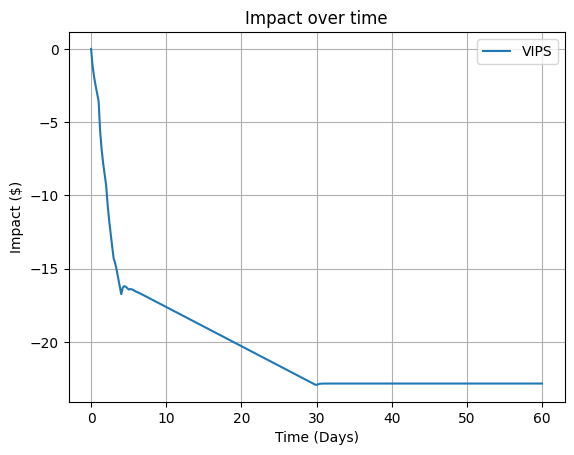

In [49]:
stock_processes = AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, "VIPS", stock_value_dict["VIPS"])
plt.plot(stock_processes.times, stock_processes.compute_impact(), label = stock_processes.stock_name)
plt.title("Impact over time")
plt.legend()    
plt.grid()
plt.xlabel("Time (Days)")
plt.ylabel("Impact ($)")
plt.show()

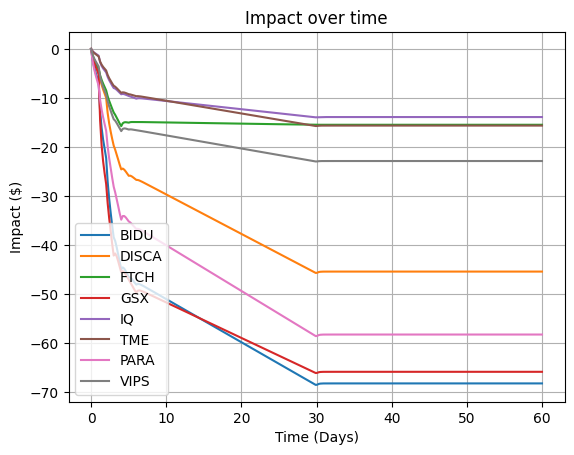

In [50]:
for name in stock_names:
    stock_processes = AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
    plt.plot(stock_processes.times, stock_processes.compute_impact(), label = stock_processes.stock_name)
plt.title("Impact over time")
plt.legend()    
plt.grid()
plt.xlabel("Time (Days)")
plt.ylabel("Impact ($)")
plt.show()


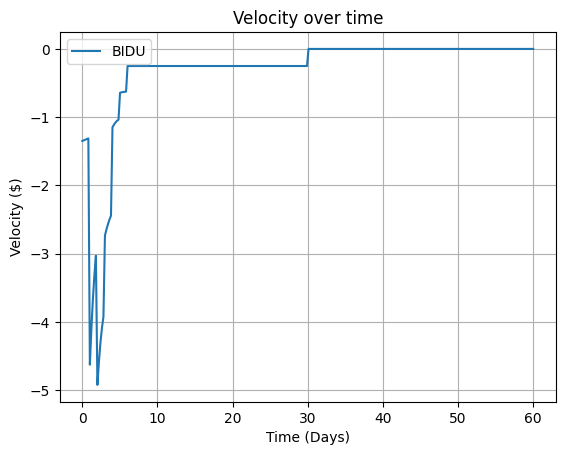

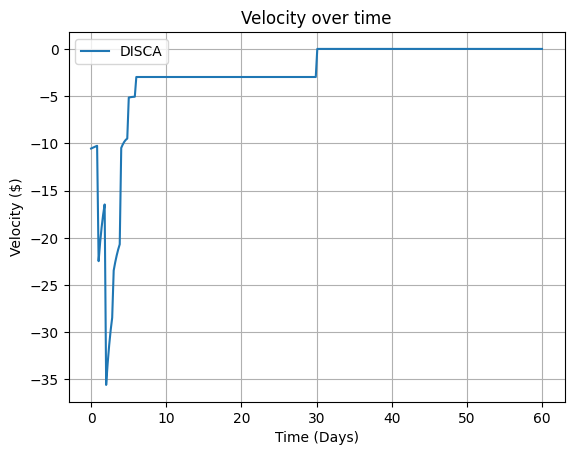

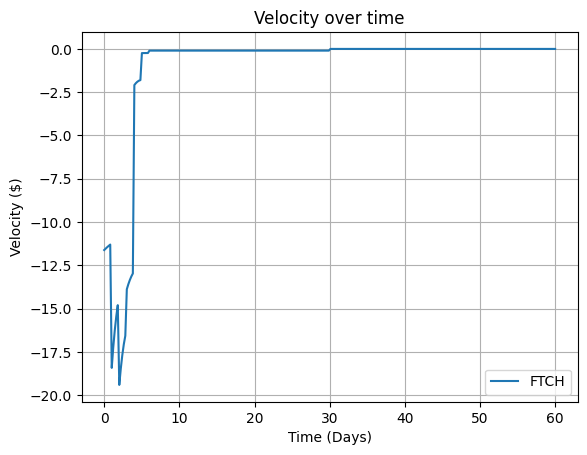

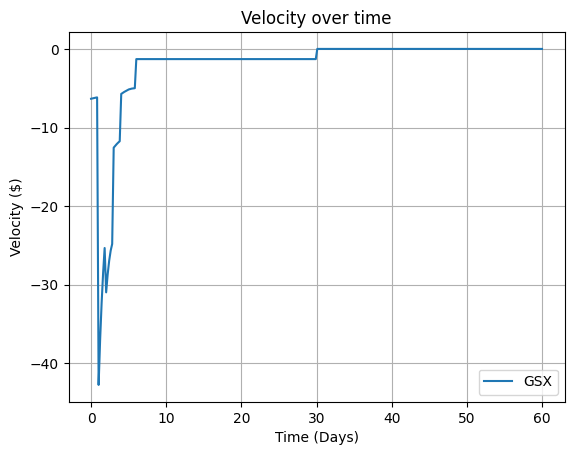

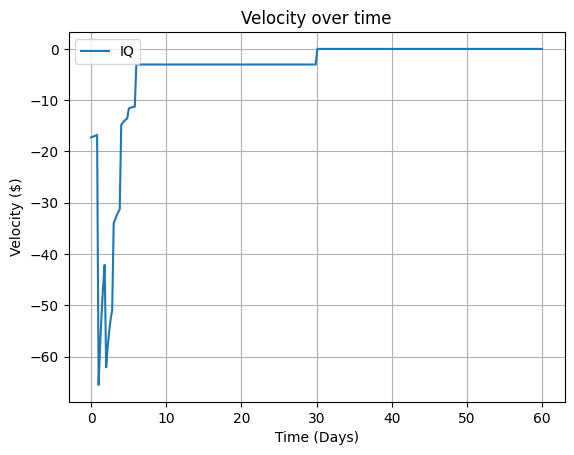

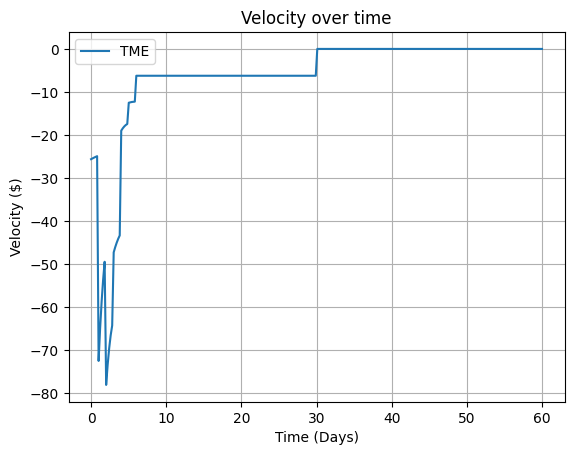

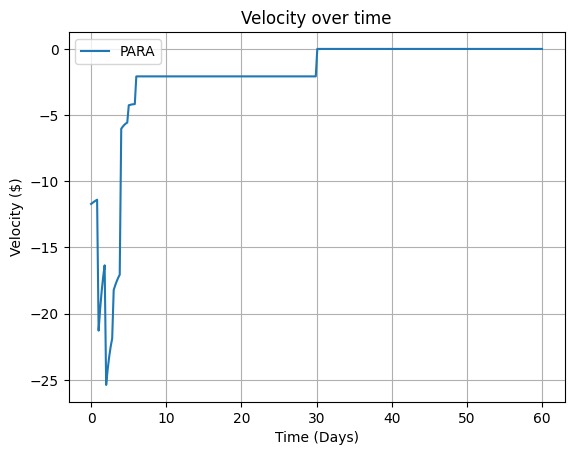

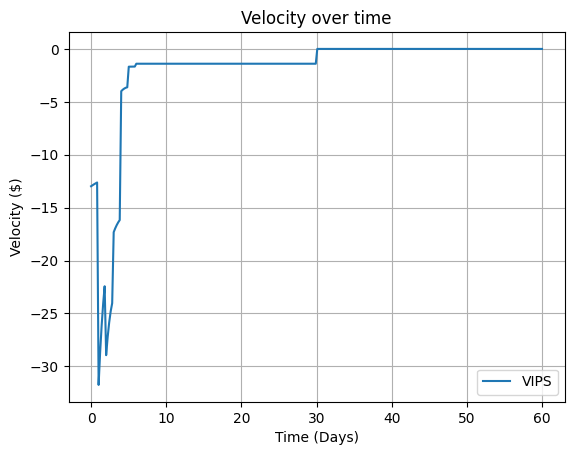

In [51]:
for name in stock_names:
    stock_processes = AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
    plt.plot(stock_processes.times, stock_processes.trading_velocity(), label = stock_processes.stock_name)
    plt.title("Velocity over time")
    plt.legend()    
    plt.grid()
    plt.xlabel("Time (Days)")
    plt.ylabel("Velocity ($)")
    plt.show()

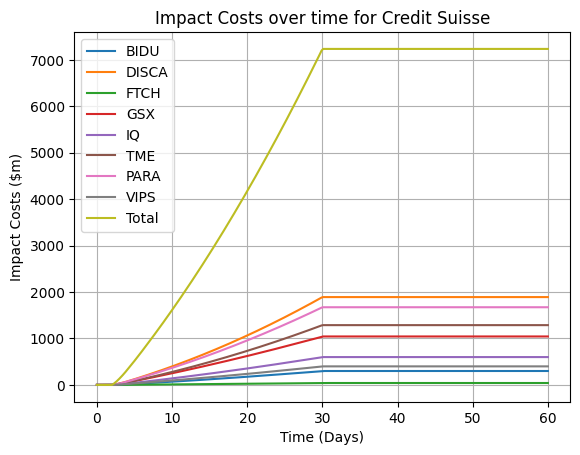

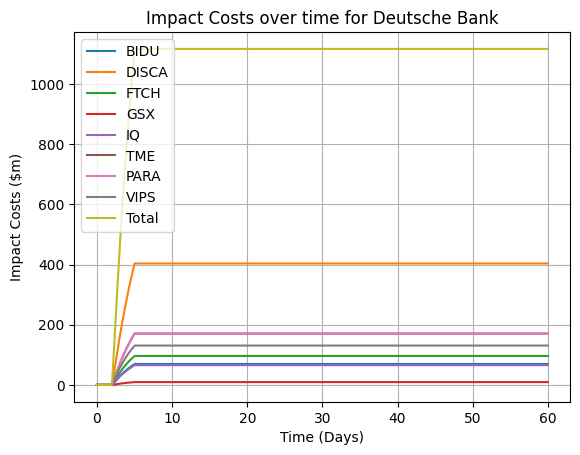

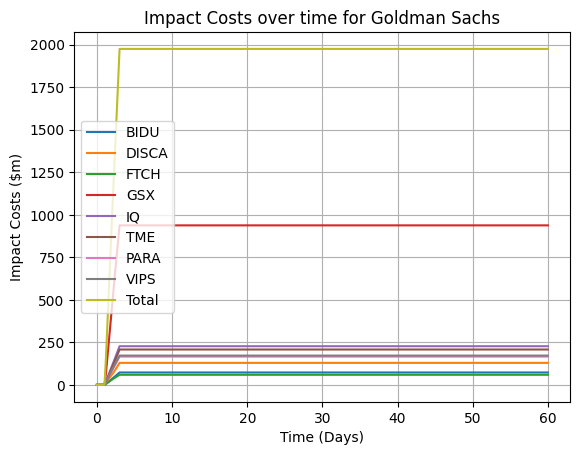

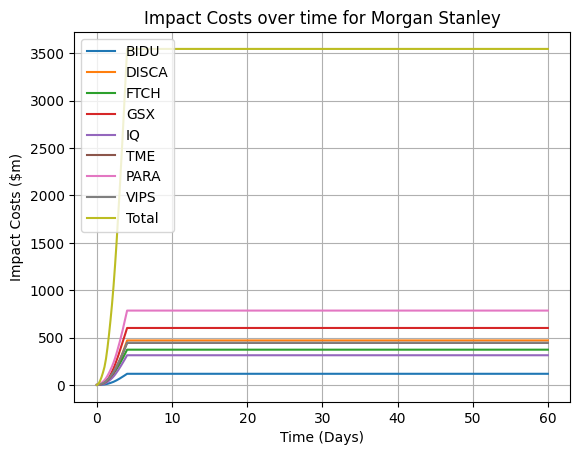

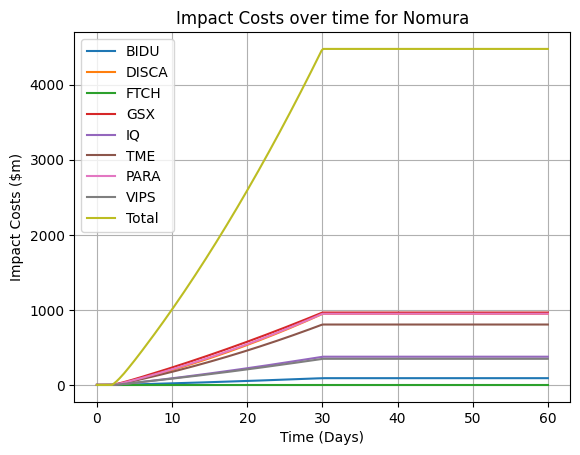

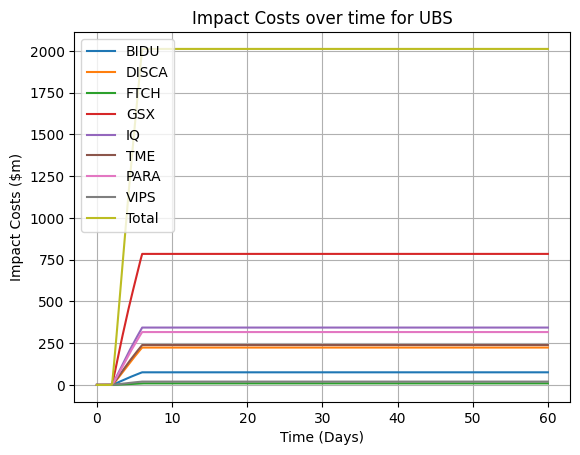

{'Credit Suisse': np.float64(7236.743203555666), 'Deutsche Bank': np.float64(1116.1458386656695), 'Goldman Sachs': np.float64(1975.0027898663068), 'Morgan Stanley': np.float64(3547.368436040336), 'Nomura': np.float64(4477.109252771743), 'UBS': np.float64(2011.9413386106303)}


In [52]:
cost_dict = {}
for agent in agent_names:
    total = 0
    for name in stock_names:
        stock_processes = AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
        costs = stock_processes.compute_impact_costs()[agent]
        total += costs
        plt.plot(stock_processes.times, costs, label = stock_processes.stock_name)
    cost_dict[agent] = total[-1]

    plt.plot(stock_processes.times, total, label = "Total")
    plt.title("Impact Costs over time for " + agent)
    plt.legend()    
    plt.grid()
    plt.xlabel("Time (Days)")
    plt.ylabel("Impact Costs ($m)")
    plt.show()
print(cost_dict)

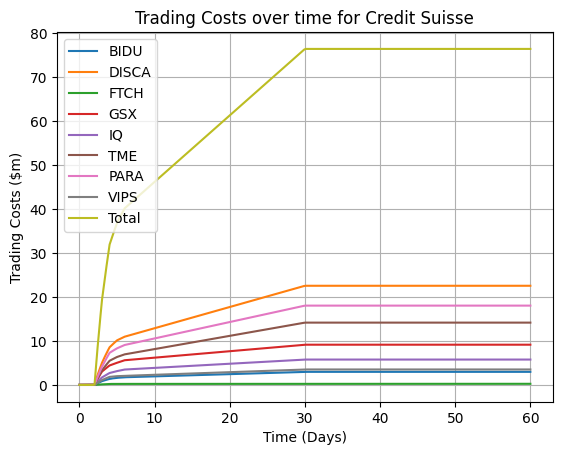

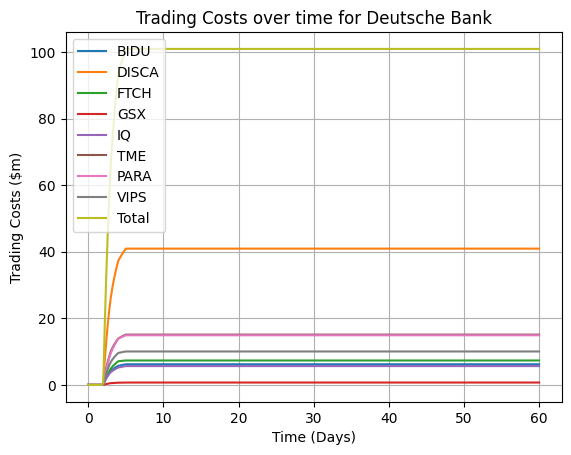

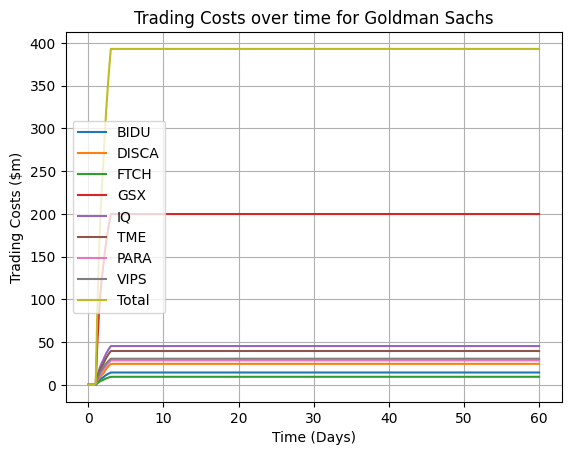

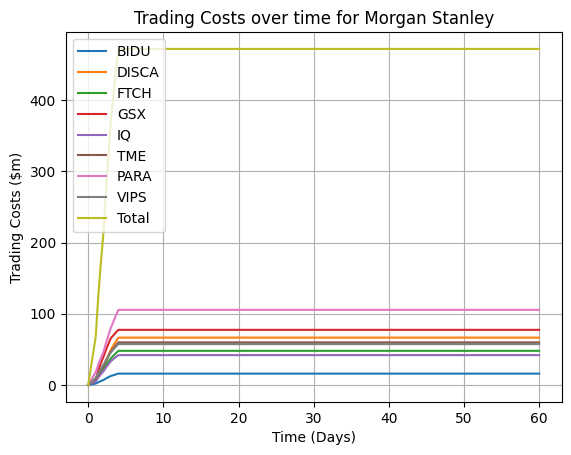

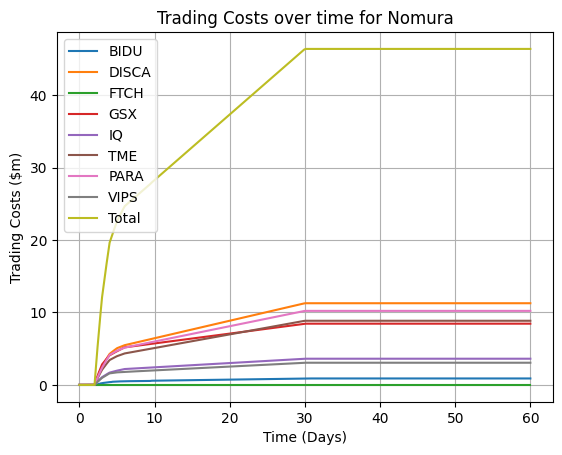

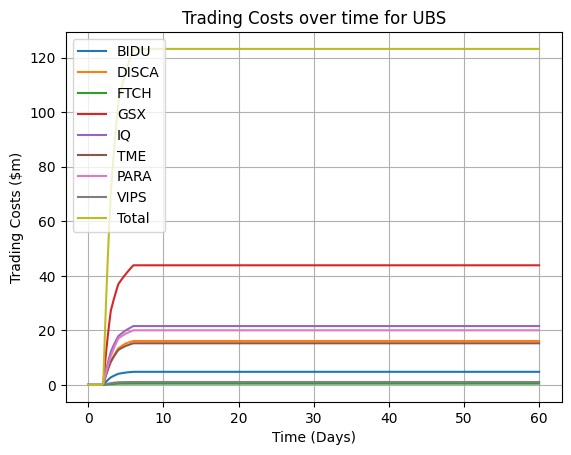

{'Credit Suisse': np.float64(76.43420763418317), 'Deutsche Bank': np.float64(100.9500051565579), 'Goldman Sachs': np.float64(392.955916706689), 'Morgan Stanley': np.float64(472.171576886374), 'Nomura': np.float64(46.38563260678651), 'UBS': np.float64(123.21835621328603)}


In [53]:
trade_cost_dict = {}
for agent in agent_names:
    total = 0
    for name in stock_names:
        stock_processes = AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
        costs = stock_processes.compute_trading_costs()[agent]
        total += costs
        plt.plot(stock_processes.times, costs, label = stock_processes.stock_name)
    cost_dict[agent] = total[-1]

    plt.plot(stock_processes.times, total, label = "Total")
    plt.title("Trading Costs over time for " + agent)
    plt.legend()    
    plt.grid()
    plt.xlabel("Time (Days)")
    plt.ylabel("Trading Costs ($m)")
    plt.show()
print(cost_dict)

In [54]:
import UnpeturbedStockPathGeneration

correlations = pd.read_pickle("correlations_2.pkl")
vols = pd.read_pickle("vols.pkl")
means = pd.read_pickle("means.pkl")

print(correlations)
print(vols)
print(means)


from scipy.linalg import cholesky
cholesky_root = cholesky(correlations)

print(cholesky_root)


           BIDU       TME      VIPS      FTCH        IQ      PARA     DISCA  \
BIDU   1.000000  0.291189  0.199336  0.250802  0.173106 -0.113877 -0.058945   
TME    0.291189  1.000000  0.198104  0.184016  0.154981 -0.093305 -0.116681   
VIPS   0.199336  0.198104  1.000000  0.166178  0.139713 -0.130125 -0.103143   
FTCH   0.250802  0.184016  0.166178  1.000000  0.007776 -0.091301 -0.121295   
IQ     0.173106  0.154981  0.139713  0.007776  1.000000 -0.091899 -0.051280   
PARA  -0.113877 -0.093305 -0.130125 -0.091301 -0.091899  1.000000  0.764065   
DISCA -0.058945 -0.116681 -0.103143 -0.121295 -0.051280  0.764065  1.000000   
GSX    0.093682  0.159803  0.094104  0.065125  0.139318  0.091714  0.059410   
NDX    0.439147  0.283106  0.228312  0.445265  0.177617 -0.019000 -0.007624   
S&P    0.385945  0.209134  0.160528  0.405337  0.180346  0.191664  0.263362   

            GSX       NDX       S&P  
BIDU   0.093682  0.439147  0.385945  
TME    0.159803  0.283106  0.209134  
VIPS   0.094104 

BIDU266.13266.13
TME30.8730.87
VIPS45.2545.25
FTCH62.062.0
IQ28.0428.04
PARA100.34100.34
DISCA74.6574.65
GSX83.7983.79


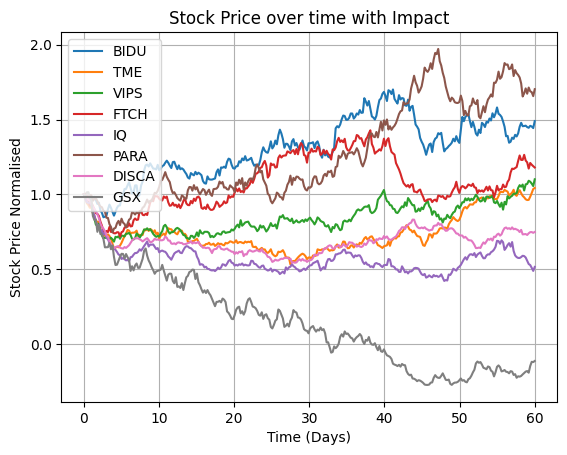

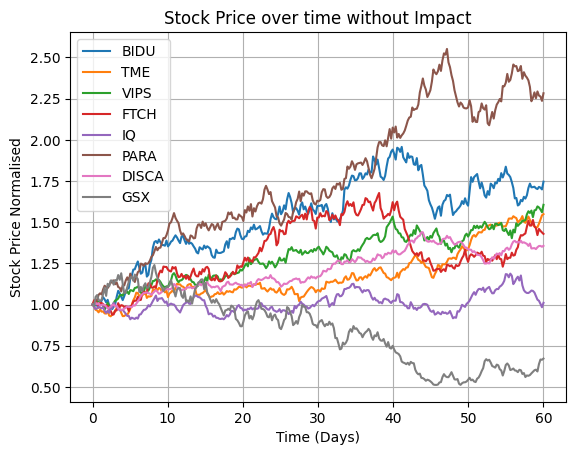

In [60]:
all_stock_and_index_values = np.array([266.13, 30.87, 45.25, 62, 28.04, 100.34, 74.65, 83.79, 13086.51, 3940.59])

stock_time_series = UnpeturbedStockPathGeneration.generate_correlated_geometric_brownians(1, 300, cholesky_root, 60/260, means, vols, all_stock_and_index_values)

excel_stock_name_order = ["BIDU", "TME", "VIPS", "FTCH", "IQ", "PARA", "DISCA", "GSX"]

i = 0
for name in excel_stock_name_order:
    stock_processes = AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
    stock_impact = stock_processes.compute_impact()
    stock_series = stock_time_series[0, :, i]
    print(name + str(stock_series[0]) + str(all_stock_and_index_values[i]))
    i += 1
    

    plt.plot(stock_processes.times, (stock_impact + stock_series)/stock_series[0], label = stock_processes.stock_name)
plt.title("Stock Price over time with Impact")
plt.legend()    
plt.grid()
plt.xlabel("Time (Days)")
plt.ylabel("Stock Price Normalised")
plt.show()

i = 0
for name in excel_stock_name_order:
    stock_processes = AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
    stock_impact = stock_processes.compute_impact()
    stock_series = stock_time_series[0, :, i]
    i += 1

    plt.plot(stock_processes.times, stock_series/stock_series[0], label = stock_processes.stock_name)
plt.title("Stock Price over time without Impact")
plt.legend()    
plt.grid()
plt.xlabel("Time (Days)")
plt.ylabel("Stock Price Normalised")
plt.show()


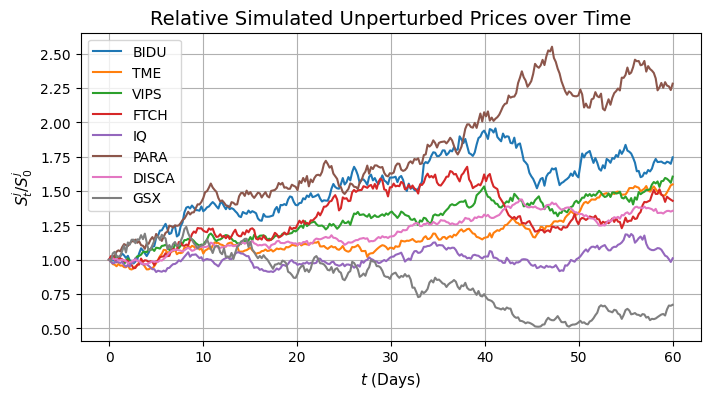

In [ ]:
def plot_thesis_size(x_size = 8, y_size = 4):
    plt.figure(figsize=(x_size, y_size))

def plot_thesis_format(title, xlabel, ylabel, legend = True, grid = True, save = False, filename = "default"):
    plt.title(title, fontsize = 14)
    if legend:
        plt.legend()    
    if grid:
        plt.grid()
    plt.xlabel(xlabel, fontsize = 11)
    plt.ylabel(ylabel, fontsize = 11)
    plt.savefig("Figures/" + filename + ".pdf", bbox_inches = 'tight')

plot_thesis_size()

i = 0
for name in excel_stock_name_order:
    stock_processes = AuxilliaryStockProcesses(times, agents, impact_functions, trading_cost_functions, name, stock_value_dict[name])
    stock_impact = stock_processes.compute_impact()
    stock_series = stock_time_series[0, :, i]
    i += 1

    plt.plot(stock_processes.times, stock_series/stock_series[0], label = stock_processes.stock_name)



plot_thesis_format("Relative Simulated Unperturbed Prices over Time", "$t$ (Days)", "$S^j_t / S^j_0$", filename = "RelativeSimulatedPricesOverTime")
plt.show()
